# Giai đoạn 4 — Sinh đặc trưng còn thiếu của hồ sơ trúng tuyển

```
┌──────────────────────────────────────────────────────────────────────────────────┐
│                                 04_SinhDacTrung                                  │
└──────────────────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 02_ChuanBiTTTH/ttth_sach.csv            —  15.696 hồ sơ (điểm + tổ hợp THẬT)
    • 03_HocPhanPhoi/phan_phoi_theo_nganh.npz —  Σ đã co ngót Bayes của mỗi ngành
    • 01_LamSachKhaoSat/khaosat_sach.csv      —  676 phiếu thật
         │
         ▼
  XỬ LÝ
    1. Giữ NGUYÊN điểm thi, tổ hợp và nhãn ngành của TTTH
    2. Gaussian copula có điều kiện theo ngành → sinh 10 câu Likert
    3. Rút giới tính và mục tiêu theo phân phối của ngành
    4. 5 ngành không có hồ sơ TTTH → bootstrap từ chính phiếu khảo sát của ngành
    5. Sinh thêm vài cấu hình GA làm ĐỐI CHỨNG
         │
         ▼
  ĐẦU RA
    • 04_SinhDacTrung/khung_ho_so.csv         —  phần THẬT giữ nguyên
    • 04_SinhDacTrung/sinh_theo_ppp.npz       —  Likert của từng phương pháp
    • 04_SinhDacTrung/hinh_4_*.png            —  4 hình
```

## Sinh cái gì, giữ nguyên cái gì

Hồ sơ trúng tuyển có **điểm thi, tổ hợp và ngành trúng tuyển CÓ THẬT** — thứ mà 676 phiếu
khảo sát không thể có nhiều. Giai đoạn này **không đụng vào chúng**.

| Cột | Ở TTTH | Xử lý |
|---|---|---|
| Ngành trúng tuyển | ✅ thật | **giữ nguyên** — đây là nhãn |
| Tổ hợp xét tuyển | ✅ thật | **giữ nguyên** |
| Điểm 3 môn | ✅ thật | **giữ nguyên** |
| 10 câu Likert | ❌ không có | **copula sinh** |
| Giới tính · mục tiêu | ❌ không có | rút theo phân phối của ngành |

## Gaussian copula có điều kiện theo ngành

Bốn bước, mỗi ngành làm riêng:

```
①  u_j = F_j(x_j)            đưa từng câu về thang đều [0,1]
                             bằng hàm phân phối THỰC NGHIỆM của ngành đó
②  z_j = Φ⁻¹(u_j)            đưa sang thang chuẩn
③  z' ~ N(0, R_ngành)        rút mẫu mới — R là tương quan của ngành
④  x'_j = F_j⁻¹(Φ(z'_j))     tra NGƯỢC hàm phân vị → về đúng thang 1..5
```

**Bước ④ là chỗ quyết định.** Nó không làm tròn — nó tra vào **đúng bảng tần suất có thật
của ngành**. Nên phân phối biên của từng câu được tái tạo gần như chính xác, chứ không bị
méo như cách lấy mẫu chuẩn rồi làm tròn.

Bước ③ giữ **cấu trúc phụ thuộc** giữa 10 câu. Người thật trả lời không độc lập — ai thích
thí nghiệm cũng thường thích môi trường (r = +0,62) và dinh dưỡng (r = +0,52). Ma trận R
giữ lại đúng mối liên hệ đó.

Và vì `z` là biến **liên tục**, hai mẫu gần như không bao giờ trùng nhau — không có chuyện
sao chép nguyên phiếu thật.

### Dùng lại đúng phần co ngót đã có

Không ước lượng lại gì cả:

- **Tương quan `R`** — lấy thẳng `Σ` đã co ngót Bayes ở Giai đoạn 3, đổi sang ma trận
  tương quan bằng `R = D⁻¹ Σ D⁻¹` với `D = diag(√Σᵢᵢ)`.
- **Phân phối biên từng câu** — co ngót về mức nhóm bằng **đúng công thức**
  `w = n/(n+8)` của Giai đoạn 3.

Nhờ vậy ngành 6 phiếu vẫn không sinh ra phân phối méo mó, và hai giai đoạn nhất quán với
nhau.

### Vì sao chỉ điều kiện theo NGÀNH, không theo điểm thi

Về nguyên tắc có thể điều kiện thêm theo điểm thi của chính hồ sơ đó. Nhưng đã đo trên
676 phiếu thật: liên hệ giữa 10 câu Likert và 10 môn điểm **rất yếu** —
`|r|` trung bình **0,105**, chỉ **9/80 cặp** vượt 0,25, và mấy cặp mạnh nhất đều rơi vào
môn Địa với n = 45 (mẫu nhỏ, nhiều khả năng là nhiễu).

Bỏ qua liên hệ đó không mất mát đáng kể, mà tránh được việc ước lượng thêm một ma trận
20×20 từ 676 dòng.

### Nguồn tham khảo

- **Sklar (1959)** — định lý nền tảng: mọi phân phối nhiều chiều tách được thành các phân
  phối biên và một copula mô tả cấu trúc phụ thuộc.
- **Patki, Wedge & Veeramachaneni (2016)**, *The Synthetic Data Vault*, IEEE DSAA —
  Gaussian copula làm lõi cho sinh dữ liệu tổng hợp dạng bảng.

## Giải thuật di truyền — giữ làm đối chứng

Cấu hình GA vẫn được sinh ra để Giai đoạn 5 chấm cạnh copula. Ba toán tử:

| Toán tử | Cách làm |
|---|---|
| Khởi tạo | lấy mẫu có hoàn lại từ phiếu thật của ngành |
| Lai ghép | cắt một điểm — vài câu của bạn A, còn lại của bạn B |
| Đột biến | thay **một** câu bằng câu trả lời của một bạn thật khác |

Hàm thích nghi bám **tập điển hình**, không bám đỉnh:

```
E[log p(x)] = −½ (d·log(2π) + log|Σ| + d)
fitness(x)  = −| log p(x) − E[log p(x)] |
```

Đặt hàm thích nghi là `log p(x)` thuần thì cả quần thể hội tụ về đúng vector trung bình.

**Số thế hệ là siêu tham số quyết định của GA**, nên quét nhiều mức. GA sinh ra để *hội
tụ*, mà bước này cần *phân tán* — mỗi dòng phải là một học sinh khác nhau. Chạy càng
nhiều thế hệ, đấu loại từng cặp càng nhân bản cá thể hợp hàm thích nghi nhất ra khắp
quần thể.

## Sinh cho TOÀN BỘ 15.696 dòng

Bảng huấn luyện ở Giai đoạn 6 sẽ có khoảng **96% dòng tổng hợp**. Con số này phải nêu rõ
khi báo cáo.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Web gửi limit=3 (web/src/app/(main)/predict/page.tsx) nên Top-3 là chỉ tiêu
# chính; Top-1/2/5 báo cáo kèm để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_HocPhanPhoi",
    4: "04_GA_TangCuong",
    5: "05_KiemDinhGA",
    6: "06_TrainFinal",
    7: "07_TachTrainTest",
    8: "08_MocChuan",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

def nap(co_test=False, co_ttth=True, co_fold=False):
    """Đọc mọi thứ notebook huấn luyện cần.

    Chia train/test diễn ra ở Giai đoạn 7,
    SAU khi bảng train final đã dựng xong. Nên:

        Giai đoạn 3–5   d["train"] = TOÀN BỘ 676 phiếu khảo sát, chưa có fold nào
        Giai đoạn 8–9   co_fold=True  → đọc train.csv và cv_folds.json của GĐ 7
        Giai đoạn 10    co_test=True  → mở tập test ĐÚNG MỘT LẦN

    Khoá "nhom" đọc từ `nganh_to_nhom` trong mapping.json — nguồn chuẩn duy nhất.
    """
    m = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
    d = {
        "likert": m["cot_likert"],
        "diem": m["cot_diem"],
        "ma_to_ten": {int(k): v for k, v in m["ma_to_ten"].items()},
        "nhom": {int(k): v for k, v in m["nganh_to_nhom"].items()},
        "ten_nhom": {int(k): v for k, v in m["ten_nhom"].items()},
        "ten_cach_nhom": m.get("ten_cach_nhom", "nhóm ngành"),
        "train": pd.read_csv(thu_muc(1) / "khaosat_sach.csv"),
    }
    d["ttth"] = pd.read_csv(thu_muc(2) / "ttth_sach.csv") if co_ttth else pd.DataFrame()
    if co_fold:
        d["train"] = pd.read_csv(thu_muc(7) / "train.csv")
        d["folds"] = json.loads((thu_muc(7) / "cv_folds.json").read_text(encoding="utf-8"))
    if co_test:
        d["test"] = pd.read_csv(thu_muc(7) / "test_KHOA.csv")

    nguon = [d["train"].to_hop_thi.str.split(" ").str[0]]
    if co_ttth:
        nguon.append(d["ttth"].to_hop_thi.astype(str))
    d["to_hop"] = sorted(set().union(*[set(s) for s in nguon]))
    d["nganh"] = np.sort(d["train"].ma_nganh.unique())
    d["i_nganh"] = {m_: i for i, m_ in enumerate(d["nganh"])}

    # Thống kê điểm để quy z-score. Tính trên TRAIN (+ TTTH nếu dùng), tuyệt đối
    # không đụng test — nếu không thì thông tin test rò rỉ qua bước chuẩn hoá.
    goc = [d["train"][d["diem"]]] + ([d["ttth"][d["diem"]]] if co_ttth else [])
    g = pd.concat(goc).astype(float)
    d["diem_mu"] = g.mean().values
    d["diem_sd"] = g.std().replace(0, 1).values
    return d


def dac_trung(df, D, co_khao_sat=True):
    """Ma trận 63 đặc trưng — MỘT định nghĩa duy nhất cho cả hai nguồn dữ liệu.

    `co_khao_sat=False` dùng cho hồ sơ trúng tuyển: nguồn này chỉ có điểm thi và
    tổ hợp. Cột thiếu để NaN chứ không điền bừa — XGBoost học luôn hướng rẽ cho
    giá trị thiếu ngay trong thuật toán, còn điền bừa tạo ra giá trị không có thật.
    """
    n = len(df)
    L, C_DIEM = D["likert"], D["diem"]
    th = df["to_hop_thi"].astype(str).str.split(" ").str[0].values
    Dm = df[C_DIEM].astype(float).values
    Lk = df[L].astype(float).values if co_khao_sat else np.full((n, len(L)), np.nan)

    ph = [pd.DataFrame(Lk, columns=L)]

    # Likert chuẩn hoá theo từng người: người hay chọn 4-5 và người hay chọn 2-3
    # cùng "thích logic nhất" nhưng để thô thì mô hình đọc thành hai hồ sơ khác
    # hẳn. Trừ trung bình của chính người đó thì còn lại sở thích TƯƠNG ĐỐI.
    with np.errstate(invalid="ignore"):
        mu = np.nanmean(Lk, 1, keepdims=True)
        sd = np.nanstd(Lk, 1, keepdims=True)
    sd = np.where((sd == 0) | np.isnan(sd), 1.0, sd)
    ph.append(pd.DataFrame(Lk - mu, columns=[f"ips_{c}" for c in L]))
    ph.append(pd.DataFrame({"likert_tb": mu[:, 0], "likert_dolech": sd[:, 0]}))

    ph.append(pd.DataFrame(Dm, columns=C_DIEM))
    # 8.0 môn Toán và 8.0 môn Văn không cùng ý nghĩa — quy z-score mới so được
    z = (Dm - D["diem_mu"]) / D["diem_sd"]
    ph.append(pd.DataFrame(z, columns=[f"z_{c}" for c in C_DIEM]))
    with np.errstate(invalid="ignore", divide="ignore"):
        ph.append(pd.DataFrame({
            "diem_tb": np.nanmean(Dm, 1),
            "diem_lech": np.nanmax(Dm, 1) - np.nanmin(Dm, 1),
            "z_tb": np.nanmean(z, 1),
            "z_max": np.nanmax(z, 1),
        }))

    # Tổ hợp là dữ liệu phân loại, KHÔNG có thứ tự. Mã hoá thành số (A00=0,
    # A01=1…) sẽ dạy mô hình rằng D01 "lớn hơn" A00 và trung bình A00 với B00 ra
    # A01 — vô nghĩa. One-hot tránh được: mỗi cột chỉ hỏi "có thi tổ hợp này không".
    ph.append(pd.DataFrame({f"th_{t}": (th == t).astype(float) for t in D["to_hop"]}))
    gt = ((df["gioi_tinh"] == "Nam").astype(float).values if "gioi_tinh" in df
          else np.full(n, np.nan))
    mt = (df["muc_tieu_ma"].astype(float).values if "muc_tieu_ma" in df
          else np.full(n, np.nan))
    ph.append(pd.DataFrame({"gioi_tinh_nam": gt, "muc_tieu": mt}))
    return pd.concat([p.reset_index(drop=True) for p in ph], axis=1)


def nhom_dac_trung(cols, D):
    """Gom tên cột thành 8 nhóm — dùng khi in bảng thống kê và vẽ hình."""
    L, C_DIEM = D["likert"], D["diem"]
    return {
        "Likert thô": [c for c in cols if c in L],
        "Likert chuẩn hoá theo người": [c for c in cols if c.startswith("ips_")],
        "Thống kê Likert": [c for c in cols if c in ("likert_tb", "likert_dolech")],
        "Điểm thi thô": [c for c in cols if c in C_DIEM],
        "Điểm z-score từng môn": [c for c in cols if c.startswith("z_diem_")],
        "Phái sinh từ điểm": [c for c in cols
                              if c in ("diem_tb", "diem_lech", "z_tb", "z_max")],
        "Tổ hợp xét tuyển (one-hot)": [c for c in cols if c.startswith("th_")],
        "Nhân khẩu học & mục tiêu": [c for c in cols
                                     if c in ("gioi_tinh_nam", "muc_tieu")],
    }

from scipy.stats import multivariate_normal, norm

OUT = thu_muc(4)
K_CO_NGOT = 8             # phải KHỚP Giai đoạn 3 — nếu không hai nơi sẽ lệch nhau
MUC = np.arange(1, 6)     # thang Likert 1..5
N_MUC_TIEU = 4
N_BOOTSTRAP = 120         # số dòng bootstrap cho ngành KHÔNG có hồ sơ TTTH

# Cấu hình GA đối chứng — Giai đoạn 5 chấm cạnh copula
DS_THE_HE = [3, 5, 20, 40]
P_LAI = 0.75
P_DOT_BIEN = 0.25
N_TINH_HOA = 3

D = nap(co_ttth=True)
ks, tt = D["train"], D["ttth"]
L, C_DIEM = D["likert"], D["diem"]
NG, I_NG = D["nganh"], D["i_nganh"]
y_ks = ks.ma_nganh.values
Lk_ks = ks[L].astype(float).values
gt_ks = (ks.gioi_tinh == "Nam").astype(float).values
nhom_sv = np.array([D["nhom"][m] for m in y_ks])

Z = np.load(thu_muc(3) / "phan_phoi_theo_nganh.npz")
MU, SIG, PNAM, PMT = Z["mu"], Z["sigma"], Z["p_nam"], Z["p_muctieu"]

co_tt = tt.ma_nganh.value_counts()
thieu = [m for m in NG if m not in co_tt.index]
print(f"Hồ sơ TTTH : {len(tt):,} dòng · phủ {len(co_tt)}/{len(NG)} ngành")
print(f"Ngành thiếu: {len(thieu)} → bootstrap {N_BOOTSTRAP} dòng/ngành từ phiếu khảo sát")
for m in thieu:
    print(f"             · {D['ma_to_ten'][m]:<40} ({int((y_ks==m).sum())} phiếu khảo sát)")
print(f"\nSẽ sinh Likert cho {len(tt) + len(thieu)*N_BOOTSTRAP:,} dòng")
print(f"Chính       : Gaussian copula có điều kiện theo ngành")
print(f"Đối chứng   : GA ở {len(DS_THE_HE)} mức thế hệ {DS_THE_HE}")

Hồ sơ TTTH : 15,696 dòng · phủ 34/39 ngành
Ngành thiếu: 5 → bootstrap 120 dòng/ngành từ phiếu khảo sát
             · Luật                                     (10 phiếu khảo sát)
             · Trí tuệ nhân tạo                         (15 phiếu khảo sát)
             · Quản lý Công nghiệp                      (7 phiếu khảo sát)
             · Logistics và quản lý chuỗi cung ứng      (10 phiếu khảo sát)
             · Du lịch                                  (10 phiếu khảo sát)

Sẽ sinh Likert cho 16,296 dòng
Chính       : Gaussian copula có điều kiện theo ngành
Đối chứng   : GA ở 4 mức thế hệ [3, 5, 20, 40]


## 1. Dựng khung hồ sơ nền — phần THẬT

In [2]:
rng = np.random.default_rng(SEED)

# Toàn bộ hồ sơ TTTH — điểm, tổ hợp, nhãn giữ NGUYÊN, không rút mẫu
khung = tt[["to_hop_thi", "ma_nganh"] + C_DIEM].copy()
khung["nguon"] = "ttth"

# 5 ngành không có hồ sơ trúng tuyển nào. Không bootstrap thì bảng huấn luyện chỉ
# có vài chục phiếu khảo sát cho mỗi ngành đó, trong khi ngành khác có hàng nghìn
# dòng — mô hình sẽ gần như không bao giờ đoán ra chúng.
if thieu:
    bs = []
    for ma in thieu:
        phieu = ks[ks.ma_nganh == ma]
        lay = rng.choice(len(phieu), N_BOOTSTRAP, replace=True)
        r = phieu.iloc[lay][["to_hop_thi"] + C_DIEM].reset_index(drop=True)
        r["to_hop_thi"] = r.to_hop_thi.astype(str).str.split(" ").str[0]
        r["ma_nganh"] = ma
        r["nguon"] = "bootstrap_khaosat"
        bs.append(r)
    khung = pd.concat([khung] + bs, ignore_index=True)

khung["j_nganh"] = khung.ma_nganh.map(I_NG)
khung["ma_nhom"] = khung.ma_nganh.map(D["nhom"])
khung = khung.reset_index(drop=True)
ma_arr = khung.ma_nganh.values

print(f"Khung hồ sơ nền: {len(khung):,} dòng · {khung.ma_nganh.nunique()}/{len(NG)} ngành")
print(khung.nguon.value_counts().to_string())
cq = khung.ma_nganh.value_counts()
print(f"\nDòng mỗi ngành: ít nhất {cq.min()} · nhiều nhất {cq.max():,}"
      f" · trung vị {int(cq.median())}")
assert khung[C_DIEM].notna().sum(axis=1).min() >= 3, "có dòng thiếu điểm"
assert khung.ma_nganh.nunique() == len(NG), "có ngành không có dòng nào"

Khung hồ sơ nền: 16,296 dòng · 39/39 ngành
nguon
ttth                 15696
bootstrap_khaosat      600

Dòng mỗi ngành: ít nhất 18 · nhiều nhất 1,832 · trung vị 345


## 2. Gaussian copula có điều kiện theo ngành

In [3]:
def pmf_co_ngot(ma):
    """Phân phối biên từng câu của một ngành, CO NGÓT về mức nhóm.

    Dùng đúng công thức w = n/(n+K) của Giai đoạn 3 để hai nơi nhất quán. Ngành
    6 phiếu mà lấy tần suất thô thì mỗi mức Likert chỉ có 0 hoặc 1 người — hàm
    phân vị dựng từ đó sẽ bậc thang rất thô.
    """
    sel = y_ks == ma
    n = int(sel.sum())
    w = n / (n + K_CO_NGOT)
    sel_nh = nhom_sv == D["nhom"][ma]
    ra = np.zeros((len(L), len(MUC)))
    for k in range(len(L)):
        p_ng = (np.bincount(Lk_ks[sel, k].astype(int) - 1, minlength=len(MUC)) / n
                if n else np.zeros(len(MUC)))
        p_nh = np.bincount(Lk_ks[sel_nh, k].astype(int) - 1,
                           minlength=len(MUC)) / sel_nh.sum()
        p = w * p_ng + (1 - w) * p_nh
        ra[k] = p / p.sum()
    return ra


def tuong_quan(S):
    """Σ → ma trận tương quan R, ép xác định dương.

    Σ đã co ngót nên hiếm khi suy biến, nhưng phép chia cho độ lệch chuẩn có thể
    đẩy vài trị riêng xuống ~0. Cắt sàn trị riêng rồi chuẩn hoá lại đường chéo.
    """
    d = np.sqrt(np.diag(S))
    R = S / np.outer(d, d)
    R = (R + R.T) / 2
    np.fill_diagonal(R, 1.0)
    w_, V = np.linalg.eigh(R)
    R = V @ np.diag(np.clip(w_, 1e-6, None)) @ V.T
    dd = np.sqrt(np.diag(R))
    return R / np.outer(dd, dd)


def copula_mot_nganh(ma, n_can, rng):
    """Bốn bước của Gaussian copula. Xem phần giải thích ở đầu notebook."""
    R = tuong_quan(SIG[I_NG[ma]])
    z = rng.multivariate_normal(np.zeros(len(L)), R, size=n_can)   # ③
    u = norm.cdf(z)                                               # ③→④
    P = pmf_co_ngot(ma)
    ra = np.zeros((n_can, len(L)))
    for k in range(len(L)):
        cum = np.cumsum(P[k])
        # Hàm phân vị của phân phối RỜI RẠC — tra u vào bảng tần suất tích luỹ.
        # Đây là chỗ phân phối biên thật được tái tạo, không phải làm tròn.
        ra[:, k] = MUC[np.searchsorted(cum, u[:, k], side="left").clip(0, len(MUC) - 1)]
    return ra


def sinh_copula(rng):
    lk = np.zeros((len(khung), len(L)))
    gt = np.zeros(len(khung))
    mt = np.zeros(len(khung), dtype=int)
    for ma in NG:
        j = I_NG[ma]
        o = np.where(ma_arr == ma)[0]
        lk[o] = copula_mot_nganh(ma, len(o), rng)
        gt[o] = (rng.random(len(o)) < PNAM[j]).astype(float)
        mt[o] = rng.choice(N_MUC_TIEU, size=len(o), p=PMT[j]) + 1
    return lk, gt, mt


t0 = time.time()
LK_CP, GT, MT = sinh_copula(np.random.default_rng(SEED))
print(f"Copula xong sau {time.time()-t0:.1f}s")
print(f"   Likert : giá trị {int(LK_CP.min())}…{int(LK_CP.max())} · dạng {LK_CP.shape}")
print(f"   đa dạng: {len(pd.DataFrame(LK_CP).drop_duplicates())/len(LK_CP):.1%}"
      f"   (khảo sát thật {len(ks[L].drop_duplicates())/len(ks):.1%})")
print(f"   Nam    : {GT.mean():.1%}   (khảo sát thật {gt_ks.mean():.1%})")

Copula xong sau 0.0s
   Likert : giá trị 1…5 · dạng (16296, 10)
   đa dạng: 96.3%   (khảo sát thật 97.6%)
   Nam    : 43.5%   (khảo sát thật 44.4%)


## 3. Giải thuật di truyền — đối chứng

In [4]:
def ga_mot_nganh(kho_that, mu, sig, n_can, rng, n_the_he):
    """Sinh `n_can` bộ câu trả lời Likert cho một ngành.

    Mọi toán tử chỉ tổ hợp lại giá trị có sẵn trong `kho_that`, không bịa giá trị
    mới — đó vừa là điểm mạnh (luôn là câu trả lời có thật) vừa là điểm yếu (dễ
    lặp lại nguyên phiếu thật khi chạy ít thế hệ).
    """
    n_gen = kho_that.shape[1]
    pp = multivariate_normal(mean=mu, cov=sig, allow_singular=True)
    _, logdet = np.linalg.slogdet(np.atleast_2d(sig))
    ll_ky_vong = -0.5 * (n_gen * np.log(2 * np.pi) + logdet + n_gen)

    def thich_nghi(Q):
        return -np.abs(pp.logpdf(Q) - ll_ky_vong)

    quan_the = kho_that[rng.integers(len(kho_that), size=n_can)].copy()
    for _ in range(n_the_he):
        f = thich_nghi(quan_the)
        tinh_hoa = quan_the[np.argsort(-f)[:N_TINH_HOA]].copy()
        a, b = rng.integers(n_can, size=(2, n_can))
        cha_me = quan_the[np.where(f[a] >= f[b], a, b)]

        # Ghép trên phần CHẴN, dòng lẻ cuối giữ nguyên. Cách viết ngây thơ
        # `cap = ... if n_can % 2 == 0 else None` khiến ngành có số dòng lẻ KHÔNG
        # BAO GIỜ lai ghép — cả một toán tử bị tắt âm thầm, không báo lỗi.
        con = cha_me.copy()
        n_chan = n_can - (n_can % 2)
        if n_chan >= 2:
            cap = rng.permutation(n_can)[:n_chan].reshape(-1, 2)
            lai = rng.random(len(cap)) < P_LAI
            cat = rng.integers(1, n_gen, size=len(cap))
            for (i, j), co_lai, c in zip(cap, lai, cat):
                if co_lai:
                    con[i, c:], con[j, c:] = cha_me[j, c:].copy(), cha_me[i, c:].copy()

        db = rng.random(n_can) < P_DOT_BIEN
        if db.any():
            idx = np.where(db)[0]
            gen = rng.integers(n_gen, size=len(idx))
            nguon = kho_that[rng.integers(len(kho_that), size=len(idx))]
            con[idx, gen] = nguon[np.arange(len(idx)), gen]

        con[:N_TINH_HOA] = tinh_hoa
        quan_the = con
    return quan_the


def sinh_ga(rng, n_the_he):
    lk = np.zeros((len(khung), len(L)))
    for ma in NG:
        j = I_NG[ma]
        o = np.where(ma_arr == ma)[0]
        kho = Lk_ks[y_ks == ma]
        if len(kho) < 2:
            kho = Lk_ks
        lk[o] = ga_mot_nganh(kho, MU[j], SIG[j], len(o), rng, n_the_he)
    return np.clip(np.rint(lk), 1, 5)


t0 = time.time()
PPP = {"copula": LK_CP}
for g in DS_THE_HE:
    PPP[f"ga_{g}"] = sinh_ga(np.random.default_rng(SEED), g)
    dd = len(pd.DataFrame(PPP[f"ga_{g}"]).drop_duplicates()) / len(khung)
    print(f"   GA {g:2d} thế hệ → đa dạng {dd:6.1%}  [{time.time()-t0:.0f}s]", flush=True)
print(f"\nTổng {len(PPP)} phương pháp trong {time.time()-t0:.0f}s")

   GA  3 thế hệ → đa dạng  79.8%  [0s]


   GA  5 thế hệ → đa dạng  82.6%  [0s]


   GA 20 thế hệ → đa dạng  67.2%  [0s]


   GA 40 thế hệ → đa dạng  34.6%  [1s]



Tổng 5 phương pháp trong 1s


   💾 hinh_4_1_cau_tao.png


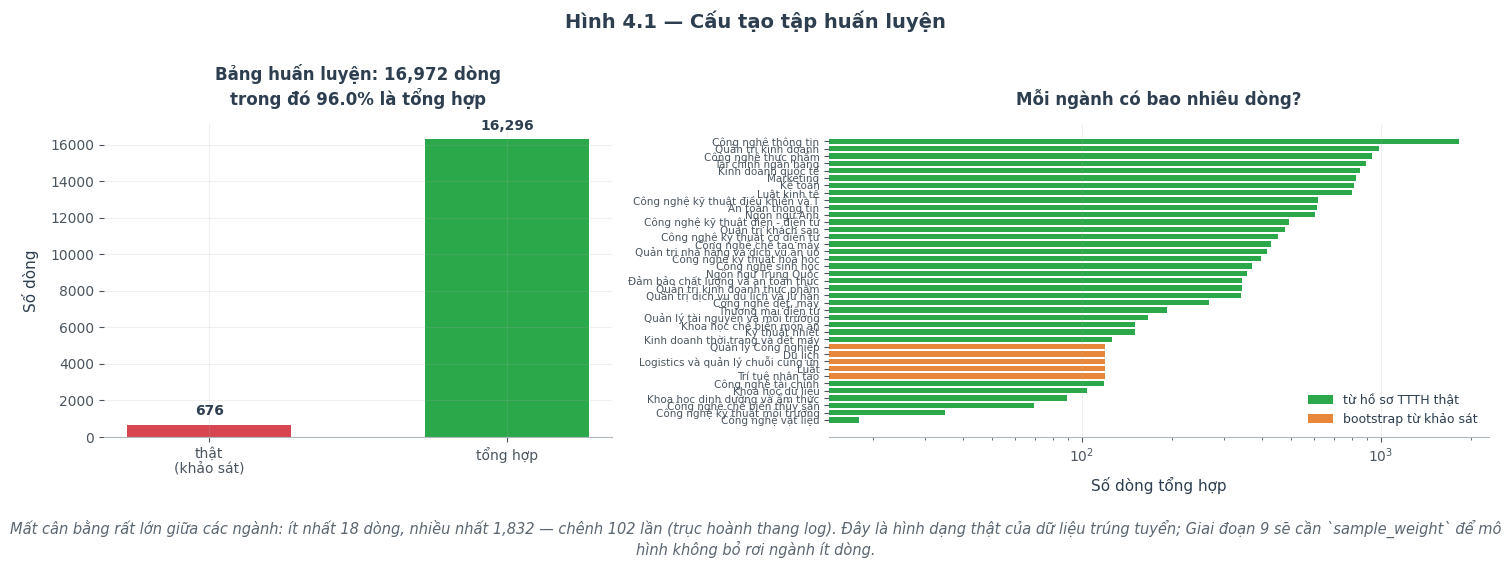

In [5]:
# ═══════════ HÌNH 4.1 — Cấu tạo tập huấn luyện ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5),
                             gridspec_kw={"width_ratios": [1, 1.3]})
n_that, n_sinh = len(ks), len(khung)
a1.bar(["thật\n(khảo sát)", "tổng hợp"], [n_that, n_sinh],
       color=[C_THAT, C_GA], width=.55)
nhan_doc(a1, fmt="{:,.0f}")
a1.set_ylabel("Số dòng")
a1.set_title(f"Bảng huấn luyện: {n_that + n_sinh:,} dòng\n"
             f"trong đó {100*n_sinh/(n_that+n_sinh):.1f}% là tổng hợp", fontsize=12)

sl = khung.ma_nganh.value_counts().sort_values()
ten = [D["ma_to_ten"][m][:34] for m in sl.index]
mau = [C_CAM if khung[khung.ma_nganh == m].nguon.iloc[0] == "bootstrap_khaosat" else C_GA
       for m in sl.index]
a2.barh(np.arange(len(sl)), sl.values, color=mau, height=.74)
a2.set_yticks(np.arange(len(sl))); a2.set_yticklabels(ten, fontsize=7.5)
a2.set_xlabel("Số dòng tổng hợp"); a2.set_xscale("log"); a2.grid(axis="y", alpha=0)
a2.set_title("Mỗi ngành có bao nhiêu dòng?", fontsize=12)
a2.legend(handles=[Patch(facecolor=C_GA, label="từ hồ sơ TTTH thật"),
                   Patch(facecolor=C_CAM, label="bootstrap từ khảo sát")],
          loc="lower right", fontsize=9)

fig.suptitle("Hình 4.1 — Cấu tạo tập huấn luyện", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_4_1_cau_tao.png",
    f"Mất cân bằng rất lớn giữa các ngành: ít nhất {sl.min()} dòng, nhiều nhất "
    f"{sl.max():,} — chênh {sl.max()/sl.min():.0f} lần (trục hoành thang log). Đây là "
    f"hình dạng thật của dữ liệu trúng tuyển; Giai đoạn 9 sẽ cần `sample_weight` để mô "
    f"hình không bỏ rơi ngành ít dòng.")
plt.show()

   💾 hinh_4_2_phan_phoi_bien.png


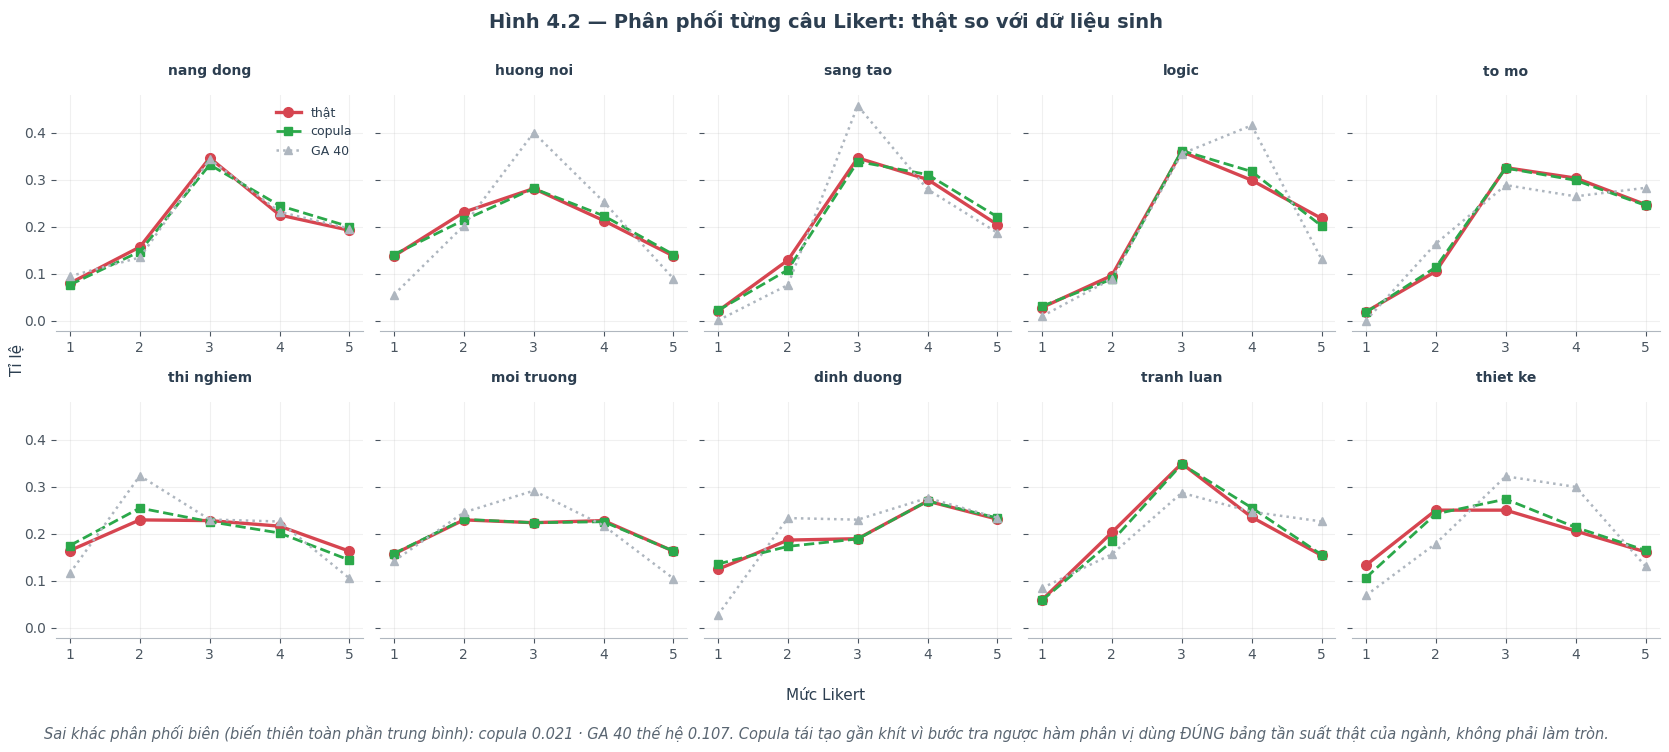

In [6]:
# ═══════════ HÌNH 4.2 — Phân phối biên từng câu ═══════════
fig, axes = plt.subplots(2, 5, figsize=(17, 7), sharey=True)
g_xau = f"ga_{max(DS_THE_HE)}"
for i, (c, ax) in enumerate(zip(L, axes.ravel())):
    that = np.bincount(Lk_ks[:, i].astype(int), minlength=6)[1:] / len(Lk_ks)
    cp = np.bincount(LK_CP[:, i].astype(int), minlength=6)[1:] / len(LK_CP)
    ga_ = np.bincount(PPP[g_xau][:, i].astype(int), minlength=6)[1:] / len(khung)
    ax.plot(MUC, that, "o-", color=C_THAT, lw=2.4, ms=7, label="thật")
    ax.plot(MUC, cp, "s--", color=C_GA, lw=2, ms=6, label="copula")
    ax.plot(MUC, ga_, "^:", color=C_XAM, lw=1.8, ms=6, label=f"GA {max(DS_THE_HE)}")
    ax.set_title(c.replace("likert_", "").replace("_", " "), fontsize=10)
    ax.set_xticks(MUC)
    if i == 0:
        ax.legend(fontsize=9)
fig.suptitle("Hình 4.2 — Phân phối từng câu Likert: thật so với dữ liệu sinh",
             fontsize=14, fontweight="bold", y=1.0)
fig.supxlabel("Mức Likert", fontsize=11); fig.supylabel("Tỉ lệ", fontsize=11)
fig.tight_layout()


def sai_bien(X):
    return np.mean([np.abs(np.bincount(X[:, k].astype(int), minlength=6)[1:] / len(X)
                           - np.bincount(Lk_ks[:, k].astype(int), minlength=6)[1:] / len(Lk_ks)
                           ).sum() / 2 for k in range(len(L))])


luu(fig, OUT, "hinh_4_2_phan_phoi_bien.png",
    f"Sai khác phân phối biên (biến thiên toàn phần trung bình): copula "
    f"{sai_bien(LK_CP):.3f} · GA {max(DS_THE_HE)} thế hệ {sai_bien(PPP[g_xau]):.3f}. "
    f"Copula tái tạo gần khít vì bước tra ngược hàm phân vị dùng ĐÚNG bảng tần suất "
    f"thật của ngành, không phải làm tròn.")
plt.show()

   💾 hinh_4_3_da_dang_sao_chep.png


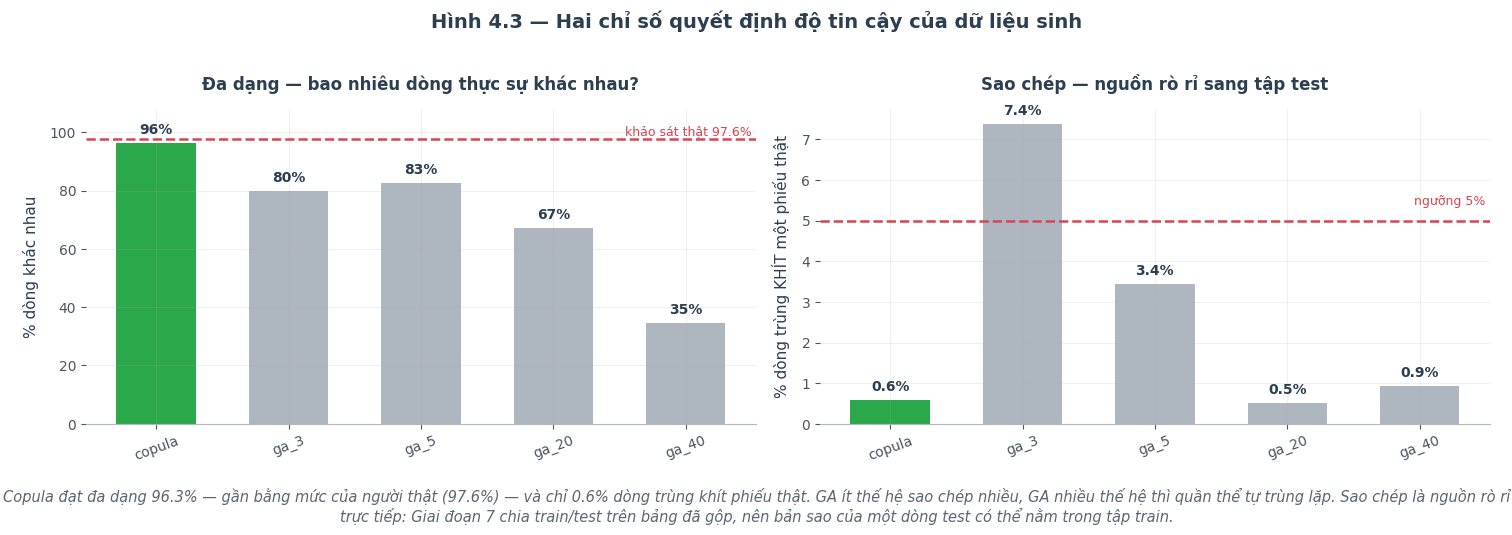

In [7]:
# ═══════════ HÌNH 4.3 — Đa dạng và sao chép ═══════════
BO_THAT = set(map(tuple, Lk_ks.astype(int)))
ten_pp = list(PPP)
dd = [len(pd.DataFrame(PPP[p]).drop_duplicates()) / len(khung) for p in ten_pp]
sc = [sum(1 for r in map(tuple, PPP[p].astype(int)) if r in BO_THAT) / len(khung)
      for p in ten_pp]
dd_that = len(ks[L].drop_duplicates()) / len(ks)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.6))
mau = [C_GA if p == "copula" else C_XAM for p in ten_pp]
a1.bar(ten_pp, [v * 100 for v in dd], color=mau, width=.6)
a1.axhline(dd_that * 100, color=C_THAT, ls="--", lw=1.8)
a1.text(len(ten_pp) - .5, dd_that * 100 + 1.5, f"khảo sát thật {dd_that:.1%}",
        fontsize=9, color=C_THAT, ha="right")
nhan_doc(a1, fmt="{:.0f}%")
a1.set_ylabel("% dòng khác nhau"); a1.set_ylim(0, 108)
a1.set_title("Đa dạng — bao nhiêu dòng thực sự khác nhau?", fontsize=12)
a1.tick_params(axis="x", rotation=20)

a2.bar(ten_pp, [v * 100 for v in sc], color=mau, width=.6)
a2.axhline(5, color=C_THAT, ls="--", lw=1.8)
a2.text(len(ten_pp) - .5, 5.4, "ngưỡng 5%", fontsize=9, color=C_THAT, ha="right")
nhan_doc(a2, fmt="{:.1f}%")
a2.set_ylabel("% dòng trùng KHÍT một phiếu thật")
a2.set_title("Sao chép — nguồn rò rỉ sang tập test", fontsize=12)
a2.tick_params(axis="x", rotation=20)

fig.suptitle("Hình 4.3 — Hai chỉ số quyết định độ tin cậy của dữ liệu sinh",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
i_cp = ten_pp.index("copula")
luu(fig, OUT, "hinh_4_3_da_dang_sao_chep.png",
    f"Copula đạt đa dạng {dd[i_cp]:.1%} — gần bằng mức của người thật ({dd_that:.1%}) — "
    f"và chỉ {sc[i_cp]:.1%} dòng trùng khít phiếu thật. GA ít thế hệ sao chép nhiều, GA "
    f"nhiều thế hệ thì quần thể tự trùng lặp. Sao chép là nguồn rò rỉ trực tiếp: Giai "
    f"đoạn 7 chia train/test trên bảng đã gộp, nên bản sao của một dòng test có thể nằm "
    f"trong tập train.")
plt.show()

   💾 hinh_4_4_tuong_quan.png


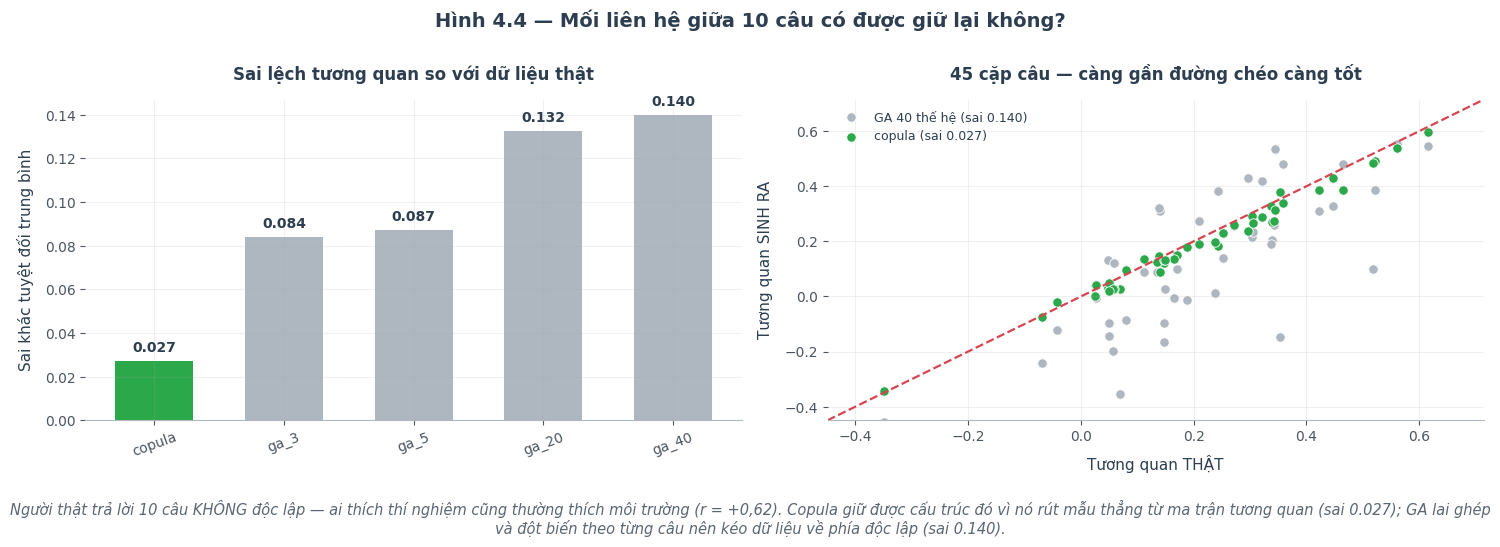

In [8]:
# ═══════════ HÌNH 4.4 — Cấu trúc tương quan ═══════════
iu = np.triu_indices(len(L), 1)
r_that = np.corrcoef(Lk_ks.T)[iu]
sai_r = {p: np.abs(np.corrcoef(PPP[p].T)[iu] - r_that).mean() for p in ten_pp}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.8))
a1.bar(ten_pp, [sai_r[p] for p in ten_pp], color=mau, width=.6)
nhan_doc(a1, fmt="{:.3f}")
a1.set_ylabel("Sai khác tuyệt đối trung bình")
a1.set_title("Sai lệch tương quan so với dữ liệu thật", fontsize=12)
a1.tick_params(axis="x", rotation=20)

a2.scatter(r_that, np.corrcoef(PPP[g_xau].T)[iu], s=46, color=C_XAM,
           label=f"GA {max(DS_THE_HE)} thế hệ (sai {sai_r[g_xau]:.3f})",
           edgecolor="white", lw=.6)
a2.scatter(r_that, np.corrcoef(LK_CP.T)[iu], s=46, color=C_GA,
           label=f"copula (sai {sai_r['copula']:.3f})", edgecolor="white", lw=.6)
lim = [r_that.min() - .1, r_that.max() + .1]
a2.plot(lim, lim, "--", color=C_THAT, lw=1.6)
a2.set_xlim(lim); a2.set_ylim(lim); a2.legend(fontsize=9)
a2.set_xlabel("Tương quan THẬT"); a2.set_ylabel("Tương quan SINH RA")
a2.set_title("45 cặp câu — càng gần đường chéo càng tốt", fontsize=12)

fig.suptitle("Hình 4.4 — Mối liên hệ giữa 10 câu có được giữ lại không?",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_4_4_tuong_quan.png",
    f"Người thật trả lời 10 câu KHÔNG độc lập — ai thích thí nghiệm cũng thường thích "
    f"môi trường (r = +0,62). Copula giữ được cấu trúc đó vì nó rút mẫu thẳng từ ma trận "
    f"tương quan (sai {sai_r['copula']:.3f}); GA lai ghép và đột biến theo từng câu nên "
    f"kéo dữ liệu về phía độc lập (sai {sai_r[g_xau]:.3f}).")
plt.show()

## 4. Xuất dữ liệu

In [9]:
khung.to_csv(OUT / "khung_ho_so.csv", index=False)
np.savez_compressed(OUT / "sinh_theo_ppp.npz",
                    ten=np.array(ten_pp),
                    likert=np.stack([PPP[p] for p in ten_pp]),
                    gioi_tinh=GT, muc_tieu=MT)

(OUT / "tom_tat.json").write_text(json.dumps({
    "n_dong": int(len(khung)),
    "n_tu_ttth": int((khung.nguon == "ttth").sum()),
    "n_bootstrap": int((khung.nguon == "bootstrap_khaosat").sum()),
    "n_nganh": int(khung.ma_nganh.nunique()),
    "phuong_phap": ten_pp,
    "chinh": "copula",
    "K_co_ngot": K_CO_NGOT,
    "ds_the_he_ga": DS_THE_HE,
    "da_dang": {p: round(d, 4) for p, d in zip(ten_pp, dd)},
    "sao_chep": {p: round(v, 4) for p, v in zip(ten_pp, sc)},
    "sai_tuong_quan": {p: round(float(v), 4) for p, v in sai_r.items()},
}, ensure_ascii=False, indent=2), encoding="utf-8")

tom_tat("GIAI ĐOẠN 4 — SINH ĐẶC TRƯNG CÒN THIẾU", [
    f"Dòng sinh ra           {len(khung):,}  × {len(ten_pp)} phương pháp",
    f"   từ hồ sơ TTTH thật  {int((khung.nguon=='ttth').sum()):,}",
    f"   bootstrap khảo sát  {int((khung.nguon=='bootstrap_khaosat').sum()):,}"
    f"  ({len(thieu)} ngành không có hồ sơ TTTH)",
    "",
    "Giữ NGUYÊN             điểm thi · tổ hợp · nhãn ngành",
    "Sinh                   10 câu Likert · giới tính · mục tiêu",
    "",
    "CHÍNH: Gaussian copula có điều kiện theo ngành",
    f"   đa dạng             {dd[i_cp]:.1%}   (khảo sát thật {dd_that:.1%})",
    f"   sao chép phiếu thật {sc[i_cp]:.1%}",
    f"   sai tương quan      {sai_r['copula']:.3f}",
    "",
    f"ĐỐI CHỨNG: GA ở {len(DS_THE_HE)} mức thế hệ {DS_THE_HE}",
] + [f"   GA {g:2d} thế hệ → đa dạng {dd[ten_pp.index(f'ga_{g}')]:.1%}"
     f" · sao chép {sc[ten_pp.index(f'ga_{g}')]:.1%}" for g in DS_THE_HE] + [
    "",
    "Giai đoạn 5 chấm cả 5 phương pháp và chọn",
])
print(f"\n✅ khung_ho_so.csv · sinh_theo_ppp.npz · 4 hình  →  {OUT}")

╔════════════════════════════════════════════════════════════════════════════╗
║                   GIAI ĐOẠN 4 — SINH ĐẶC TRƯNG CÒN THIẾU                   ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Dòng sinh ra           16,296  × 5 phương pháp                             ║
║    từ hồ sơ TTTH thật  15,696                                              ║
║    bootstrap khảo sát  600  (5 ngành không có hồ sơ TTTH)                  ║
║                                                                            ║
║ Giữ NGUYÊN             điểm thi · tổ hợp · nhãn ngành                      ║
║ Sinh                   10 câu Likert · giới tính · mục tiêu                ║
║                                                                            ║
║ CHÍNH: Gaussian copula có điều kiện theo ngành                             ║
║    đa dạng             96.3%   (khảo sát thật 97.6%)                       ║
║    sao chép phiếu thật 0.6%                       